In [18]:
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Estimator
import matplotlib.pyplot as plt 
import numpy as np 
from qiskit.quantum_info import Statevector, random_clifford 
import os

In [19]:
from tomography import SelfGuidedTomography, Mean_Direct_Fidelity

In [20]:
NQ = 2
MDF = Mean_Direct_Fidelity(NQ)
state = np.random.randn( 2**NQ )
state = state / np.linalg.norm( state )

In [21]:
Omega = random_clifford( NQ ).to_circuit()
state = np.array( Statevector(Omega) )
state

array([ 2.29934717e-17+0.00000000e+00j,  0.00000000e+00+2.29934717e-17j,
        0.00000000e+00+7.07106781e-01j, -7.07106781e-01+0.00000000e+00j])

In [22]:
MDF.Chi( state, None ).round(2)

array([ 0.5+0.j,  0. +0.j,  0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
       -0.5+0.j,  0. +0.j, -0.5+0.j,  0. +0.j])

In [23]:
alpha = 0 #1 / 2**NQ
MDF.Chi( state, truncation=alpha ).round(2)

array([ 0.5+0.j,  0. +0.j,  0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
       -0.5+0.j,  0. +0.j, -0.5+0.j,  0. +0.j])

In [24]:
np.outer( state, state.conj() ).round(2)

array([[ 0. +0.j ,  0. -0.j ,  0. -0.j , -0. -0.j ],
       [ 0. +0.j ,  0. +0.j ,  0. +0.j ,  0. -0.j ],
       [ 0. +0.j ,  0. +0.j ,  0.5+0.j ,  0. -0.5j],
       [-0. +0.j ,  0. +0.j ,  0. +0.5j,  0.5+0.j ]])

### Initial Parameters

In [25]:
NQs = [2, 3, 4, 6, 8]
L = len(NQs)
N = 10
Niter = 1000
shots = 1000
simulator_ideal=Estimator(backend_options={'shots': shots,
                                           'method': "stabilizer",},
                          transpile_options={'optimization_level': 0},
                         ) 

In [26]:
from joblib import Parallel, delayed

def simulate( NQ, simulator ):

    d = 2**NQ

    Omega = random_clifford( NQ ).to_circuit()
    OmegaM=np.outer(np.array(Statevector(Omega)),
                    (np.array(Statevector(Omega))).conj()) 

    psi0 = np.random.rand(d) + 1j * np.random.rand(d)
    psi0 = psi0 / np.linalg.norm(psi0)
    guess = psi0

    MDF = Mean_Direct_Fidelity(NQ)

    purities  = []
    stop_measuring_flag = [False]
    def stop_measuring(MDF):

        if stop_measuring_flag[0]:
            return True
        
        purities.append(MDF.Purity)
        diffs = np.diff(purities[-3:])
        
        conditions = np.isclose(diffs, 0.0, atol=1e-5)
        if len(conditions) < 2:
            conditions = [False]
        
        all_conditions = np.all(conditions) and (MDF.Purity > 0.9)
        
        if all_conditions:
            stop_measuring_flag[0] = True
            print("Stopping measurement")
        
        return all_conditions

    def I_ex(x):
        return 1 - MDF.MeanFidelity(1, 
                                    4*NQ**2, 
                                    x,
                                    Omega,
                                    simulator,
                                    truncation = None,
                                    stop_measuring = stop_measuring,  )
    
    def I_th(x):
        return 1 - np.vdot( x, OmegaM@x )/(np.linalg.norm( x ))**2

    Fidelities = []
    Measures = []
    Last=[]
    norms = []
    def callback( i, x ):
        Last.append(x)
        Fidelities.append( I_th(x) )
        Measures.append(MDF.num_exp_meas)
        nnn = np.linalg.norm( list( MDF.Measures.values() ) )**2
        norms.append( nnn )
        return None

    SelfGuidedTomography( I_ex, 
                            guess, 
                            num_iter=1000, 
                            callback = callback,
                            )
    
    Results=[np.array(Fidelities), 
                np.array(Measures), 
                np.array(Last),
                np.array( norms )
                ] 

    return Results  #j index the average over the Hilbert space 


In [27]:
from joblib import Parallel, delayed

iterator = np.repeat(NQs, N).flatten()

R = Parallel(n_jobs=-1, verbose=11)(delayed(simulate)(int(NQ),simulator_ideal) for NQ in iterator)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.


Stopping measurement


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done   3 out of  50 | elapsed:    3.5s remaining:   55.5s


Stopping measurement
Stopping measurement
Stopping measurement


[Parallel(n_jobs=-1)]: Done   8 out of  50 | elapsed:    4.7s remaining:   24.7s


...

[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed: 41.3min remaining:  6.7min


Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement


[Parallel(n_jobs=-1)]: Done  48 out of  50 | elapsed: 43.3min remaining:  1.8min


Stopping measurement


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 45.2min finished


In [28]:
Fids, Meas, _, Norm = [[[R[i + j * N][r] for i in range(N)] for j in range(len(NQs))]
                   for r in range(4)]

Fids = np.real(Fids)
Meas = np.array(Meas)
Norm = np.array(Norm) 

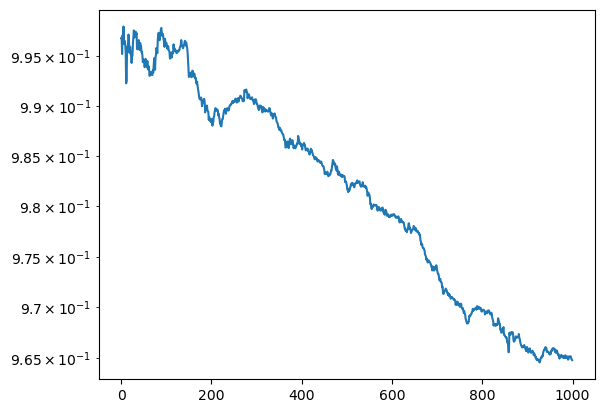

In [29]:
plt.semilogy( np.mean(Fids[-1], axis=0) )

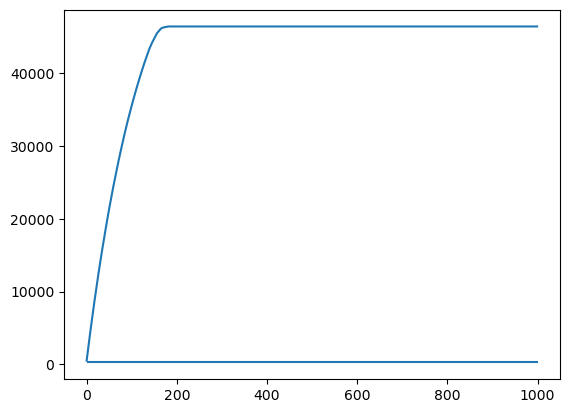

In [30]:
plt.plot( np.mean(Meas[-1], axis=0) )
plt.hlines(  4**4, 0, 1000  )

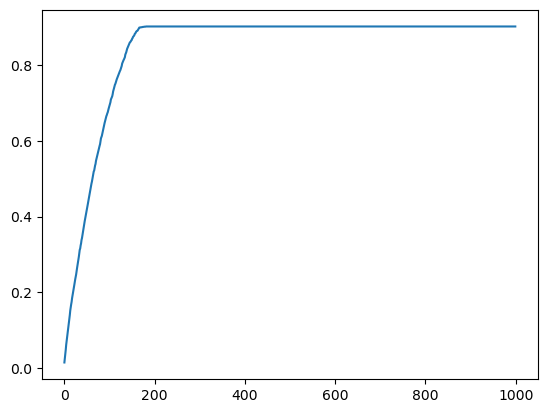

In [31]:
plt.plot( np.mean(Norm[-1], axis=0) )

In [32]:
# Save data. Ax order Fids and Meas are: [NQ, Nrun, Niter]

filename = "sgqt_without_truncation_stop.npz"

data = {
    "N": [N],
    "shots": [shots],
    "Niter": [Niter],
    "NQs": NQs,
    "Fids": Fids,
    "Meas": Meas,
    "info": ["N, shots, and Niter are single integers in one array each.",
             "NQs is the array of number of qubits.",
             "Fids and Meas have shapes (len(NQs), N, Niter)"],
}

# Make directory "data" if not present
os.makedirs("data", exist_ok=True)

# Save
filepath = os.path.join("data", filename)
np.savez(filepath, **data)